# Heston Calibration via COS Method

COS method {cite:p}`FangOosterlee2008` prices options directly from the characteristic function using Fourier-cosine expansion. Two approaches exist:

1. **Gil-Pelaez (midpoint)**: Numerical quadrature of $\int_0^\infty \text{Re}[\cdot] du$ - O(1/N) convergence
2. **COS (Fang-Oosterlee)**: Fourier series with payoff coefficients $V_k$ - exponential convergence

We calibrate Heston to synthetic market data using both pricing objectives (MSE of prices) and IV objectives (MSE of implied vols).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy.optimize import minimize
import warnings
import time

import sys
sys.path.insert(0, '..')
from utils import Heston_CF, Heston_price, bs_call_price, bs_vega, implied_vol

sys.path.insert(0, '../greeks')
from cos_greeks import cos_price

## COS Pricing: Direct Formula

The proper Fang-Oosterlee formula (Eq. 17-23 from the paper):

$$C = K e^{-rT} \sum_{k=0}^{N-1}{}' \text{Re}[H_k] \cdot V_k$$

where:
- $H_k = \phi(\omega_k) \exp(i\omega_k(x_0 - a))$ with $x_0 = \ln(S_0/K)$
- $V_k$ = payoff coefficients from $\chi_k$, $\psi_k$ (analytical for calls/puts)
- $\omega_k = k\pi/(b-a)$

No CDF recovery needed - payoff is encoded directly in $V_k$. Implementation in `greeks/cos_greeks.py`.

In [2]:
def Heston_price_COS(S0, K, T, r, kappa, nu0, theta, xi, rho, N=128):
    """Heston call price via COS method. """
    # CF of log-returns: phi(u) for ln(S_T/S_0)
    # Heston_CF gives E[exp(iu*ln(S_T))], so divide by S0^{iu}
    def cf(u):
        return Heston_CF(u, S0, T, r, kappa, nu0, theta, xi, rho) / S0**(1j*u)

    # time-averaged variance for domain truncation
    # E[∫v_s ds] / T ≈ (ν₀ - θ)(1 - e^{-κT})/(κT) + θ
    if abs(kappa * T) > 1e-8:
        avg_var = (nu0 - theta) / (kappa * T) * (1 - np.exp(-kappa * T)) + theta
    else:
        avg_var = nu0  # small T limit
    std = np.sqrt(max(avg_var, 1e-6))

    return cos_price(S0, K, T, r, cf, N=N, L=10, opt_type='call', std=std)

## Validation: COS vs Gil-Pelaez

Both methods should match - they're computing the same integral, just with different discretizations.

In [3]:
# test params
S0 = 100
r = 0.05
kappa, nu0, theta, xi, rho = 0.8, 0.3**2, 0.3**2, 0.5, -0.8

test_cases = [
    (80, 0.25),
    (100, 0.5),
    (120, 1.0),
    (90, 0.25),
    (110, 0.5),
]

print(f"{'K':>6} {'T':>6} {'Gil-Pelaez':>12} {'COS':>12} {'Diff':>12}")
print("-" * 50)

for K, T in test_cases:
    price_mid = Heston_price(S0, K, T, r, kappa, nu0, theta, xi, rho)
    price_cos = Heston_price_COS(S0, K, T, r, kappa, nu0, theta, xi, rho)
    diff = abs(price_mid - price_cos)
    print(f"{K:>6.0f} {T:>6.2f} {price_mid:>12.6f} {price_cos:>12.6f} {diff:>12.2e}")

     K      T   Gil-Pelaez          COS         Diff
--------------------------------------------------
    80   0.25    21.672486    21.673670     1.18e-03
   100   0.50     9.324225     9.323819     4.06e-04
   120   1.00     4.396639     4.396657     1.82e-05
    90   0.25    13.210964    13.211971     1.01e-03
   110   0.50     4.452337     4.452662     3.25e-04


## Synthetic Market Data

15 options across 3 maturities. Generate "market" prices from **known Heston parameters** - this allows validating calibration by checking parameter recovery.

In [4]:
# "true" Heston parameters (what we want to recover)
r = 0.05
S0 = 100
true_kappa = 1.5
true_nu0 = 0.04      # vol = 20%
true_theta = 0.06    # vol = 24.5%
true_xi = 0.4
true_rho = -0.7
true_params = [true_kappa, true_nu0, true_theta, true_xi, true_rho]

# generate market data from true Heston model via Gil-Pelaez
K_mkt = [95, 97.5, 100, 102.5, 105] * 3
T_mkt = [0.25]*5 + [0.5]*5 + [1.0]*5

Price_mkt = [Heston_price(S0, K_mkt[i], T_mkt[i], r, *true_params) for i in range(15)]
IV_mkt = [implied_vol(Price_mkt[i], S0, K_mkt[i], r, T_mkt[i]) for i in range(15)]

print(f"True params: kappa={true_kappa}, nu0={true_nu0:.4f}, theta={true_theta:.4f}, xi={true_xi}, rho={true_rho}")
print(f"Feller check: 2*kappa*theta - xi^2 = {2*true_kappa*true_theta - true_xi**2:.4f} > 0\n")

print("Market data (generated from true Heston):")
print(f"{'K':>8} {'T':>6} {'IV':>8} {'Price':>10}")
for i in range(15):
    print(f"{K_mkt[i]:>8.1f} {T_mkt[i]:>6.2f} {IV_mkt[i]:>8.1%} {Price_mkt[i]:>10.4f}")

True params: kappa=1.5, nu0=0.0400, theta=0.0600, xi=0.4, rho=-0.7
Feller check: 2*kappa*theta - xi^2 = 0.0200 > 0

Market data (generated from true Heston):
       K      T       IV      Price
    95.0   0.25    21.9%     8.0247
    97.5   0.25    21.2%     6.2630
   100.0   0.25    20.5%     4.7075
   102.5   0.25    19.7%     3.3778
   105.0   0.25    19.0%     2.2885
    95.0   0.50    22.2%    10.3924
    97.5   0.50    21.5%     8.6966
   100.0   0.50    20.9%     7.1375
   102.5   0.50    20.3%     5.7308
   105.0   0.50    19.7%     4.4887
    95.0   1.00    22.6%    14.2345
    97.5   1.00    22.2%    12.6119
   100.0   1.00    21.7%    11.0814
   102.5   1.00    21.2%     9.6491
   105.0   1.00    20.8%     8.3205


## Calibration Setup

Objective functions and constraints. Feller condition $2\kappa\theta > \xi^2$ ensures variance stays positive.

In [5]:
# params = [kappa, nu0, theta, xi, rho]

def MSE_Price_COS(params):
    """MSE between market and model prices using COS."""
    mse = 0
    for i in range(len(T_mkt)):
        model_price = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params)
        mse += (model_price - Price_mkt[i])**2
    return mse / len(T_mkt)

def MSE_IV_COS(params):
    """MSE between market and model implied vols using COS."""
    mse = 0
    for i in range(len(T_mkt)):
        model_price = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params)
        model_iv = implied_vol(model_price, S0, K_mkt[i], r, T_mkt[i])
        mse += (model_iv - IV_mkt[i])**2
    return mse / len(T_mkt)

# Gil-Pelaez versions for comparison
def MSE_Price_midpoint(params):
    mse = 0
    for i in range(len(T_mkt)):
        model_price = Heston_price(S0, K_mkt[i], T_mkt[i], r, *params)
        mse += (model_price - Price_mkt[i])**2
    return mse / len(T_mkt)

def MSE_IV_midpoint(params):
    mse = 0
    for i in range(len(T_mkt)):
        model_price = Heston_price(S0, K_mkt[i], T_mkt[i], r, *params)
        model_iv = implied_vol(model_price, S0, K_mkt[i], r, T_mkt[i])
        mse += (model_iv - IV_mkt[i])**2
    return mse / len(T_mkt)

# constraints
cons = (
    {'type': 'ineq', 'fun': lambda x: 1.0 - x[4]},      # rho <= 1
    {'type': 'ineq', 'fun': lambda x: x[4] + 1.0},      # rho >= -1
    {'type': 'ineq', 'fun': lambda x: x[3] - 1e-5},     # xi > 0
    {'type': 'ineq', 'fun': lambda x: x[0] - 1e-5},     # kappa > 0
    {'type': 'ineq', 'fun': lambda x: x[1] - 1e-5},     # nu0 > 0
    {'type': 'ineq', 'fun': lambda x: x[2] - 1e-5},     # theta > 0
    # Feller: 2*kappa*theta - xi^2 > 0 (with buffer to avoid boundary saturation)
    {'type': 'ineq', 'fun': lambda x: 2 * x[0] * x[2] - x[3]**2 - 0.01}
)

## Per-Call Timing: COS vs Gil-Pelaez

Single pricing call benchmark.

In [6]:
# benchmark single pricing call
K_test, T_test = 100, 0.5
params_test = [0.8, 0.06, 0.06, 0.5, -0.7]

# warmup
_ = Heston_price(S0, K_test, T_test, r, *params_test)
_ = Heston_price_COS(S0, K_test, T_test, r, *params_test)

n_calls = 100

t0 = time.time()
for _ in range(n_calls):
    Heston_price(S0, K_test, T_test, r, *params_test)
time_midpoint = (time.time() - t0) / n_calls * 1000  # ms

t0 = time.time()
for _ in range(n_calls):
    Heston_price_COS(S0, K_test, T_test, r, *params_test)
time_cos = (time.time() - t0) / n_calls * 1000  # ms

print(f"Single pricing call ({n_calls} runs avg):")
print(f"  Gil-Pelaez: {time_midpoint:.3f} ms")
print(f"  COS:        {time_cos:.3f} ms")
print(f"  Speedup:    {time_midpoint/time_cos:.1f}x")

Single pricing call (100 runs avg):
  Gil-Pelaez: 6.023 ms
  COS:        0.172 ms
  Speedup:    35.1x


## Calibration: Price Objective (COS)

In [7]:
warnings.filterwarnings('ignore')

# initial params: [kappa, nu0, theta, xi, rho]
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

t0 = time.time()
result_price_cos = minimize(MSE_Price_COS, params0, constraints=cons, method='SLSQP', tol=1e-6)
time_price_cos = time.time() - t0

params_price_cos = result_price_cos['x']
print(f"Calibration (Price MSE, COS) completed in {time_price_cos:.2f}s\n")
print(f"{'Param':>8} {'Calibrated':>12} {'True':>12} {'Rel Error':>12}")
print("-" * 48)
param_names = ['kappa', 'nu0', 'theta', 'xi', 'rho']
for i, name in enumerate(param_names):
    calib = params_price_cos[i]
    true = true_params[i]
    rel_err = abs(calib - true) / abs(true) if abs(true) > 1e-10 else abs(calib - true)
    print(f"{name:>8} {calib:>12.4f} {true:>12.4f} {rel_err:>11.2%}")
print(f"\nFeller: 2*kappa*theta - xi^2 = {2*params_price_cos[0]*params_price_cos[2] - params_price_cos[3]**2:.4f} > 0")

Calibration (Price MSE, COS) completed in 0.11s

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa       2.0245       1.5000      34.97%
     nu0       0.0396       0.0400       1.02%
   theta       0.0558       0.0600       7.03%
      xi       0.3980       0.4000       0.49%
     rho      -0.7717      -0.7000      10.24%

Feller: 2*kappa*theta - xi^2 = 0.0674 > 0


## Calibration: IV Objective (COS)

In [8]:
# same starting point for fair comparison
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

t0 = time.time()
result_iv_cos = minimize(MSE_IV_COS, params0, constraints=cons, method='SLSQP', tol=1e-10)
time_iv_cos = time.time() - t0

params_iv_cos = result_iv_cos['x']
print(f"Calibration (IV MSE, COS) completed in {time_iv_cos:.2f}s\n")
print(f"{'Param':>8} {'Calibrated':>12} {'True':>12} {'Rel Error':>12}")
print("-" * 48)
for i, name in enumerate(param_names):
    calib = params_iv_cos[i]
    true = true_params[i]
    rel_err = abs(calib - true) / abs(true) if abs(true) > 1e-10 else abs(calib - true)
    print(f"{name:>8} {calib:>12.4f} {true:>12.4f} {rel_err:>11.2%}")
print(f"\nFeller: 2*kappa*theta - xi^2 = {2*params_iv_cos[0]*params_iv_cos[2] - params_iv_cos[3]**2:.4f} > 0")

Calibration (IV MSE, COS) completed in 0.61s

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa       2.0114       1.5000      34.10%
     nu0       0.0395       0.0400       1.18%
   theta       0.0554       0.0600       7.63%
      xi       0.3800       0.4000       4.99%
     rho      -0.7883      -0.7000      12.62%

Feller: 2*kappa*theta - xi^2 = 0.0785 > 0


## Calibration Results: IV Smile Fit

Compare the calibrated model's IV smile against market across maturities. Both calibration objectives (price MSE and IV MSE) should produce similar fits since market data is Heston-consistent.

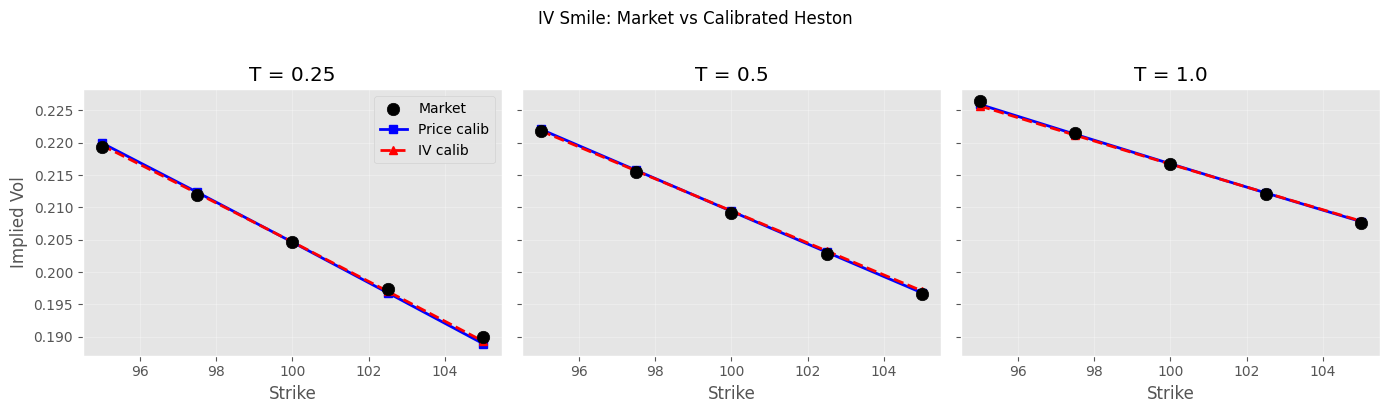

In [9]:
# compute model IVs for both calibrations
IV_price_cos = [implied_vol(Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params_price_cos), 
                            S0, K_mkt[i], r, T_mkt[i]) for i in range(15)]
IV_iv_cos = [implied_vol(Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params_iv_cos), 
                         S0, K_mkt[i], r, T_mkt[i]) for i in range(15)]

# reshape for plotting by maturity
K_unique = [95, 97.5, 100, 102.5, 105]
T_unique = [0.25, 0.5, 1.0]

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for j, T in enumerate(T_unique):
    idx = slice(j*5, (j+1)*5)
    
    # market IV (scatter)
    axs[j].scatter(K_unique, IV_mkt[idx], s=80, c='black', marker='o', 
                   label='Market', zorder=3)
    
    # calibrated models (lines)
    axs[j].plot(K_unique, IV_price_cos[idx], 'b-', lw=2, marker='s', 
                markersize=6, label='Price calib')
    axs[j].plot(K_unique, IV_iv_cos[idx], 'r--', lw=2, marker='^', 
                markersize=6, label='IV calib')
    
    axs[j].set_xlabel('Strike')
    axs[j].set_title(f'T = {T}')
    axs[j].grid(True, alpha=0.3)

axs[0].set_ylabel('Implied Vol')
axs[0].legend(loc='upper right')

plt.suptitle('IV Smile: Market vs Calibrated Heston', y=1.02)
plt.tight_layout()
plt.show()

## Full Calibration Timing: COS vs Gil-Pelaez

In [10]:
# run Gil-Pelaez calibrations for timing comparison (same starting points)
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

t0 = time.time()
result_price_mid = minimize(MSE_Price_midpoint, params0, constraints=cons, method='SLSQP', tol=1e-6)
time_price_mid = time.time() - t0

t0 = time.time()
result_iv_mid = minimize(MSE_IV_midpoint, params0, constraints=cons, method='SLSQP', tol=1e-10)
time_iv_mid = time.time() - t0

print("Full calibration times:")
print(f"{'Objective':>15} {'Gil-Pelaez':>12} {'COS':>12} {'Speedup':>10}")
print("-" * 50)
print(f"{'Price MSE':>15} {time_price_mid:>11.2f}s {time_price_cos:>11.2f}s {time_price_mid/time_price_cos:>9.1f}x")
print(f"{'IV MSE':>15} {time_iv_mid:>11.2f}s {time_iv_cos:>11.2f}s {time_iv_mid/time_iv_cos:>9.1f}x")

Full calibration times:
      Objective   Gil-Pelaez          COS    Speedup
--------------------------------------------------
      Price MSE        9.16s        0.11s      83.3x
         IV MSE       12.67s        0.61s      20.7x


## Heston's Limitation: U-Shaped Smiles

Real markets often exhibit U-shaped smiles — elevated IV for both OTM puts and calls. Heston can only produce **monotonic skew** (via ρ < 0), not convexity. This is a structural limitation.

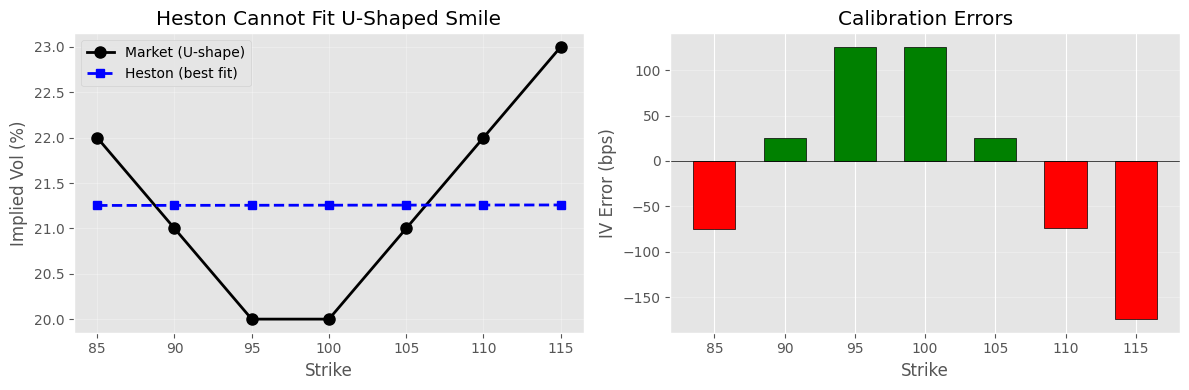

Calibrated rho = 0.943 (pushed toward +1 → flat smile)
Max IV error: 174 bps


In [11]:
# U-shaped market smile (cannot be produced by Heston)
K_smile = np.array([85, 90, 95, 100, 105, 110, 115])
T_smile = 0.5

# symmetric U-shape: ATM = 20%, both wings elevated equally
# this is the case Heston CANNOT fit (produces skew, not smile)
IV_smile_mkt = np.array([0.22, 0.21, 0.20, 0.20, 0.21, 0.22, 0.23])
Price_smile_mkt = [bs_call_price(S0, K_smile[i], r, IV_smile_mkt[i], T_smile) 
                   for i in range(len(K_smile))]

# calibrate Heston to this U-shaped data
def MSE_smile(params):
    mse = 0
    for i in range(len(K_smile)):
        model_price = Heston_price_COS(S0, K_smile[i], T_smile, r, *params)
        mse += (model_price - Price_smile_mkt[i])**2
    return mse / len(K_smile)

result_smile = minimize(MSE_smile, params0, constraints=cons, method='SLSQP', tol=1e-6)
params_smile = result_smile['x']

# compute calibrated model IVs
IV_smile_model = [implied_vol(Heston_price_COS(S0, K_smile[i], T_smile, r, *params_smile),
                              S0, K_smile[i], r, T_smile) for i in range(len(K_smile))]

# plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# left: smile fit
ax1.plot(K_smile, IV_smile_mkt * 100, 'ko-', lw=2, markersize=8, label='Market (U-shape)')
ax1.plot(K_smile, np.array(IV_smile_model) * 100, 'b--s', lw=2, markersize=6, label='Heston (best fit)')
ax1.set_xlabel('Strike')
ax1.set_ylabel('Implied Vol (%)')
ax1.set_title('Heston Cannot Fit U-Shaped Smile')
ax1.legend()
ax1.grid(True, alpha=0.3)

# right: IV errors
errors_bps = (np.array(IV_smile_model) - IV_smile_mkt) * 10000
colors = ['green' if e > 0 else 'red' for e in errors_bps]
ax2.bar(K_smile, errors_bps, color=colors, width=3, edgecolor='black')
ax2.axhline(0, color='black', lw=0.5)
ax2.set_xlabel('Strike')
ax2.set_ylabel('IV Error (bps)')
ax2.set_title('Calibration Errors')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Calibrated rho = {params_smile[4]:.3f} (pushed toward +1 → flat smile)")
print(f"Max IV error: {max(abs(errors_bps)):.0f} bps")

## Heston-SLV: Fitting Arbitrary Smiles

Heston produces skew (monotonic), not smile (U-shape). The Stochastic Local Volatility (SLV) model fixes this via a leverage function:

$$L^2(K, T) = \frac{\sigma^2_{\text{Dupire}}(K, T)}{\mathbb{E}[v_T | S_T = K]}$$

The `cppfm` library implements Van der Stoep's iterative calibration. Key feature: pass an external `VolatilitySurface` to match arbitrary market smiles.

SLV converged in 9 iterations


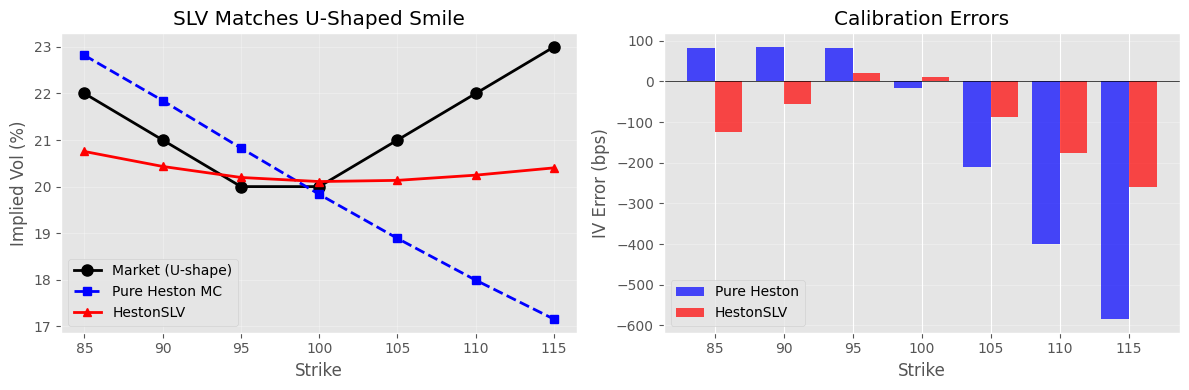


Max |error| Pure Heston: 585 bps
Max |error| HestonSLV:   260 bps


In [12]:
import cppfm

# same U-shaped smile from above
curve = cppfm.FlatDiscountCurve(r)
market_strikes = list(K_smile)
market_maturities = [0.25, 0.5, 1.0]

# build external surface from U-shaped IVs
def usmile_iv(K, atm=0.20):
    return atm + 0.6 * np.log(K / S0)**2

market_vols = [[usmile_iv(K) for K in market_strikes] for _ in market_maturities]
external_surface = cppfm.VolatilitySurface(market_strikes, market_maturities, market_vols, curve)

# Heston model (same params as calibrated above)
heston = cppfm.HestonModel(S0, curve, v0=0.04, kappa=2.0, vbar=0.04, sigma_v=0.3, rho=-0.7)

# pure Heston MC (no SLV)
n_paths = 50000
test_steps = list(np.linspace(0, T_smile, 127))
heston_sim = cppfm.HestonSLVSimulator(heston, test_steps, n_paths, 25, seed=42)
heston_terminals = heston_sim.simulate()

heston_mc_ivs = []
for K in K_smile:
    payoff = sum(max(s - K, 0) for s, _ in heston_terminals)
    price = np.exp(-r * T_smile) * payoff / n_paths
    heston_mc_ivs.append(cppfm.bs_implied_volatility(S0, K, r, T_smile, price, cppfm.OptionType.Call))
heston_mc_ivs = np.array(heston_mc_ivs)

# HestonSLV with external surface
slv_sim = cppfm.HestonSLVSimulator(heston, external_surface, test_steps, n_paths, num_bins=25, seed=42)
iters = slv_sim.calibrate_leverage(30, 1e-3, 0.5)
print(f"SLV converged in {iters} iterations")

slv_terminals = slv_sim.simulate()
slv_ivs = []
for K in K_smile:
    payoff = sum(max(s - K, 0) for s, _ in slv_terminals)
    price = np.exp(-r * T_smile) * payoff / n_paths
    slv_ivs.append(cppfm.bs_implied_volatility(S0, K, r, T_smile, price, cppfm.OptionType.Call))
slv_ivs = np.array(slv_ivs)

# plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_smile, IV_smile_mkt * 100, 'ko-', lw=2, markersize=8, label='Market (U-shape)')
ax1.plot(K_smile, heston_mc_ivs * 100, 'b--s', lw=2, markersize=6, label='Pure Heston MC')
ax1.plot(K_smile, slv_ivs * 100, 'r-^', lw=2, markersize=6, label='HestonSLV')
ax1.set_xlabel('Strike')
ax1.set_ylabel('Implied Vol (%)')
ax1.set_title('SLV Matches U-Shaped Smile')
ax1.legend()
ax1.grid(True, alpha=0.3)

# errors
heston_err = (heston_mc_ivs - IV_smile_mkt) * 10000
slv_err = (slv_ivs - IV_smile_mkt) * 10000
x = np.arange(len(K_smile))
ax2.bar(x - 0.2, heston_err, 0.4, label='Pure Heston', color='blue', alpha=0.7)
ax2.bar(x + 0.2, slv_err, 0.4, label='HestonSLV', color='red', alpha=0.7)
ax2.axhline(0, color='black', lw=0.5)
ax2.set_xlabel('Strike')
ax2.set_ylabel('IV Error (bps)')
ax2.set_title('Calibration Errors')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{k:.0f}' for k in K_smile])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nMax |error| Pure Heston: {np.max(np.abs(heston_err)):.0f} bps")
print(f"Max |error| HestonSLV:   {np.max(np.abs(slv_err)):.0f} bps")